# PSM-DID Analysis: Impact of Green Bonds on Firm Performance

This notebook implements a rigorous **Propensity Score Matching - Difference in Differences (PSM-DID)** framework to estimate the causal impact of Green Bond issuance on corporate financial and environmental performance.

## Methodology Outline
1. **Pre-processing**: Handling panel data structure and creating treatment indicators.
2. **Propensity Score Matching (PSM)**: Matching issuers to non-issuers based on pre-treatment characteristics to reduce selection bias.
3. **Diagnostics**:
   - Balance Check (Standardized Mean Differences)
   - Multicollinearity (VIF)
   - Parallel Trends Assumption (Dynamic DiD/Event Study)
4. **DiD Estimation**: Estimating Average Treatment Effect on the Treated (ATET) with clustered standard errors.
5. **Robustness**: Sensitivity analysis and prior estimates impact.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from statsmodels.stats.outliers_influence import variance_inflation_factor
from linearmodels.panel import PanelOLS

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# ========== LOAD AND PREPARE DATA ==========
# Load the processed panel data
df = pd.read_csv('../processed_data/selected_features_panel_data.csv')

# Ensure proper panel structure
df = df.sort_values(['company', 'Year'])

# Define Treatment Group: Ever issued a Green Bond
df['is_issuer'] = df.groupby('company')['green_bond_issue'].transform('max') > 0

# Define 'Post' period relative to the FIRST issuance
df['issue_year'] = df.apply(
    lambda x: x['Year'] if x['green_bond_issue'] > 0 else np.nan, 
    axis=1
)
df['first_issue_year'] = df.groupby('company')['issue_year'].transform('min')
df['post'] = (df['Year'] >= df['first_issue_year']).astype(int)

# Ensure certified_bond_active exists for H3 testing
if 'certified_bond_active' not in df.columns:
    df['certified_bond_active'] = 0  # Placeholder if not in data

print(f"Data Loaded Successfully")
print(f"  Total Observations: {len(df)}")
print(f"  Number of Green Bond Issuers: {df[df['is_issuer'] == True]['company'].nunique()}")
print(f"  Number of Non-Issuers: {df[df['is_issuer'] == False]['company'].nunique()}")
print(f"  Years Covered: {df['Year'].min()} to {df['Year'].max()}")


Total Observations: 43197
Number of Issuers: 22


## 1. Propensity Score Matching (PSM)

To address selection bias, we match issuers with non-issuers based on their characteristics in the year **before** their first issuance (or a proxy year for non-issuers).

In [2]:
# Load matched data (PSM has already been applied in preprocessing)
# Here we verify that PSM matching was successful by checking balance

# Features for matching (pre-treatment characteristics)
matching_features = ['L1_Firm_Size', 'L1_Leverage', 'L1_Asset_Turnover', 'L1_Capital_Intensity']

# Prepare data for PSM: use the year before first issuance for issuers
psm_df = df.copy()
psm_df['baseline_year'] = np.where(psm_df['is_issuer'], psm_df['first_issue_year'] - 1, np.nan)

# Treated baseline-year distribution (calendar years)
treated_baseline_years = (
    psm_df.loc[psm_df['is_issuer'], 'baseline_year']
    .dropna()
    .astype(int)
    .values
)
if len(treated_baseline_years) == 0:
    raise ValueError('No treated baseline years available for PSM.')

rng = np.random.default_rng(42)
control_years = (
    psm_df.loc[~psm_df['is_issuer']]
        .groupby('company')['Year']
        .apply(lambda s: sorted(s.dropna().unique().astype(int)))
)
control_baseline_map = {}
for firm, years in control_years.items():
    target = int(rng.choice(treated_baseline_years))
    nearest = min(years, key=lambda y: abs(y - target))
    control_baseline_map[firm] = nearest

psm_df.loc[~psm_df['is_issuer'], 'baseline_year'] = (
    psm_df.loc[~psm_df['is_issuer'], 'company'].map(control_baseline_map)
)

baseline_df = psm_df[psm_df['Year'] == psm_df['baseline_year']].copy()
baseline_df = baseline_df.dropna(subset=matching_features + ['is_issuer'])

X = baseline_df[matching_features]
y = baseline_df['is_issuer'].astype(int)

# ========== Logistic Regression for Propensity Scores ==========
logit_model = sm.Logit(y, sm.add_constant(X))
result = logit_model.fit(disp=0)
baseline_df['propensity_score'] = result.predict(sm.add_constant(X))

# Standardize propensity scores for caliper matching
_eps = 1e-6
baseline_df['ps_logit'] = np.log(
    (baseline_df['propensity_score'] + _eps) / 
    (1 - baseline_df['propensity_score'] + _eps)
)

# Standardize matching features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ========== 1:1 Nearest Neighbor Matching with Caliper ==========
treated = baseline_df[baseline_df['is_issuer'] == 1].copy()
control = baseline_df[baseline_df['is_issuer'] == 0].copy()

print(f"Pre-match: {len(treated)} treated, {len(control)} controls")

# Fit KNN on control group
nn = NearestNeighbors(n_neighbors=1, algorithm='auto')
control_scaled = scaler.transform(control[matching_features])
nn.fit(control_scaled)

# Find nearest neighbor for each treated unit
treated_scaled = scaler.transform(treated[matching_features])
distances, indices = nn.kneighbors(treated_scaled)

# Apply caliper (match only if distance < 0.1 SD)
caliper = 0.1
matched_pairs = []
matched_controls_used = set()

for i, (treated_idx, control_idx) in enumerate(zip(treated.index, indices.flatten())):
    if distances[i][0] < caliper:
        control_actual_idx = control.iloc[control_idx].name
        if control_actual_idx not in matched_controls_used:
            matched_pairs.append((treated_idx, control_actual_idx))
            matched_controls_used.add(control_actual_idx)

treated_matched = baseline_df.loc[[p[0] for p in matched_pairs]].copy()
control_matched = baseline_df.loc[[p[1] for p in matched_pairs]].copy()

print(f"Post-match: {len(treated_matched)} treated matched with {len(control_matched)} controls")
print(f"Caliper (max distance): {caliper} SDs")

# ========== Balance Table: Standardized Mean Differences ==========
def compute_smd(treated_data, control_data, var):
    '''Compute Standardized Mean Difference (SMD)'''
    t_mean = treated_data[var].mean()
    c_mean = control_data[var].mean()
    pooled_std = np.sqrt(
        (treated_data[var].std()**2 + control_data[var].std()**2) / 2
    )
    if pooled_std > 0:
        smd = (t_mean - c_mean) / pooled_std
    else:
        smd = 0
    return smd

# Pre-match balance
pre_balance = []
for var in matching_features:
    smd = compute_smd(treated, control, var)
    pre_balance.append({
        'Variable': var,
        'Pre-Match SMD': smd,
        'Treated Mean': treated[var].mean(),
        'Control Mean': control[var].mean(),
        'Treated SD': treated[var].std(),
        'Control SD': control[var].std()
    })

# Post-match balance
post_balance = []
for var in matching_features:
    smd = compute_smd(treated_matched, control_matched, var)
    post_balance.append({
        'Variable': var,
        'Post-Match SMD': smd,
        'Treated Mean': treated_matched[var].mean(),
        'Control Mean': control_matched[var].mean(),
        'Treated SD': treated_matched[var].std(),
        'Control SD': control_matched[var].std()
    })

# Combine and display
pre_balance_df = pd.DataFrame(pre_balance)
post_balance_df = pd.DataFrame(post_balance)

balance_comparison = pre_balance_df[['Variable', 'Pre-Match SMD']].merge(
    post_balance_df[['Variable', 'Post-Match SMD']], on='Variable'
)
balance_comparison['SMD Improvement'] = (
    balance_comparison['Pre-Match SMD'].abs() - balance_comparison['Post-Match SMD'].abs()
)

print("\n" + "="*80)
print("BALANCE TABLE: Standardized Mean Differences (SMD)")
print("="*80)
print(balance_comparison.to_string(index=False))
print("\nNote: |SMD| < 0.1 indicates good balance (rule of thumb)")
print("      Green values = successfully balanced")

# Create matched dataset by taking treated as is, and pairing controls
df_matched = pd.concat([
    treated_matched.assign(matched_group='treated'),
    control_matched.assign(matched_group='control')
])

# Re-merge with the full panel to get all years (not just baseline)
df_matched_baseline = df_matched[['company', 'matched_group']].drop_duplicates()
df_matched = df.merge(df_matched_baseline, on='company', how='inner')

print(f"\nFinal matched panel size: {df_matched.shape}")
print(f"Unique firms in matched sample: {df_matched['company'].nunique()}")
print(f"Years covered: {df_matched['Year'].min()} to {df_matched['Year'].max()}")


Propensity Score Model Summary:
                          Coef.  Std.Err.         z         P>|z|     [0.025  \
const                -10.041246  1.400514 -7.169687  7.516949e-13 -12.786203   
L1_Firm_Size           0.418391  0.080160  5.219466  1.794393e-07   0.261281   
L1_Leverage            1.349069  0.876756  1.538705  1.238763e-01  -0.369341   
L1_Asset_Turnover     -3.043000  1.111800 -2.737002  6.200184e-03  -5.222089   
L1_Capital_Intensity  -2.760808  5.716142 -0.482985  6.291067e-01 -13.964241   

                        0.975]  
const                -7.296289  
L1_Firm_Size          0.575501  
L1_Leverage           3.067480  
L1_Asset_Turnover    -0.863912  
L1_Capital_Intensity  8.442624  
Caliper (0.2*SD of logit PS): 0.4812

Common support region: [0.0003, 0.1006]
Treated in common support: 35, Control in common support: 3006
Matched pairs: 35 (treated matched: 35, controls matched: 35)
Unmatched treated (outside caliper or no controls left): 0
Matched sample: 43 firms, 8

In [ ]:
# ========== Construct DiD Variables ==========
# DiD = (is_issuer) × (post-issuance indicator)

# For each treated firm, mark the issuance year and all subsequent years as 'post'
df_matched['post_issuance'] = 0

for firm in df_matched[df_matched['is_issuer'] == 1]['company'].unique():
    first_issue = df_matched[df_matched['company'] == firm]['first_issue_year'].iloc[0]
    df_matched.loc[(df_matched['company'] == firm) & (df_matched['Year'] >= first_issue), 'post_issuance'] = 1

# Main DiD: is_issuer × post_issuance
df_matched['did'] = df_matched['is_issuer'] * df_matched['post_issuance']

# H3: Certified vs Non-Certified Bonds
df_matched['did_certified'] = df_matched['is_issuer'] * df_matched['post_issuance'] * df_matched['certified_bond_active']
df_matched['did_non_certified'] = df_matched['is_issuer'] * df_matched['post_issuance'] * (1 - df_matched['certified_bond_active'])

print(f'DiD indicator created:')
print(f'  Treated-Post observations: {(df_matched["did"] == 1).sum()}')
print(f'  Certified-Post observations: {(df_matched["did_certified"] == 1).sum()}')
print(f'  Non-Certified-Post observations: {(df_matched["did_non_certified"] == 1).sum()}')
print(f'\nSummary of DiD variables:')
print(df_matched[['company', 'Year', 'is_issuer', 'post_issuance', 'did', 'certified_bond_active', 'did_certified', 'did_non_certified']].head(15))


### 1.1 Balance Table: Standardized Mean Differences (SMD)

After matching, we verify covariate balance by comparing standardized mean differences between treatment and control groups. SMD < 0.1 indicates good balance.

In [ ]:
# Display balance table from PSM output
# (Already computed in Cell 3 - this cell displays and interprets results)

print("\n" + "="*80)
print("BALANCE TABLE INTERPRETATION")
print("="*80)

if 'balance_comparison' in locals():
    print("\nStandardized Mean Differences (SMD):")
    print(balance_comparison.to_string(index=False))
    
    good_balance = (balance_comparison['Post-Match SMD'].abs() < 0.1).sum()
    total = len(balance_comparison)
    print(f"\nBalance Assessment: {good_balance}/{total} variables have SMD < 0.1")
    print("✅ PSM successfully balanced the groups" if good_balance >= total-1 else "⚠️  Some variables still imbalanced")
else:
    print("Balance table not yet computed. Run Cell 3 first.")



## 2. Diagnostics

### 2.1 Multicollinearity (VIF)

In [3]:
def calc_vif(X_df):
    vif = pd.DataFrame()
    vif["variables"] = X_df.columns
    vif["VIF"] = [variance_inflation_factor(X_df.values, i) for i in range(X_df.shape[1])]
    return vif

features_to_check = ['L1_Firm_Size', 'L1_Leverage', 'L1_Asset_Turnover', 'L1_Capital_Intensity', 'did']
vif_data = df_matched[features_to_check].dropna()
print(calc_vif(vif_data))

              variables       VIF
0          L1_Firm_Size  3.472554
1           L1_Leverage  3.667500
2     L1_Asset_Turnover  1.299938
3  L1_Capital_Intensity  1.164432
4                   did  1.315000


### 2.2 Parallel Trends Assumption

We use an event study design by creating leads and lags relative to the issuance year.

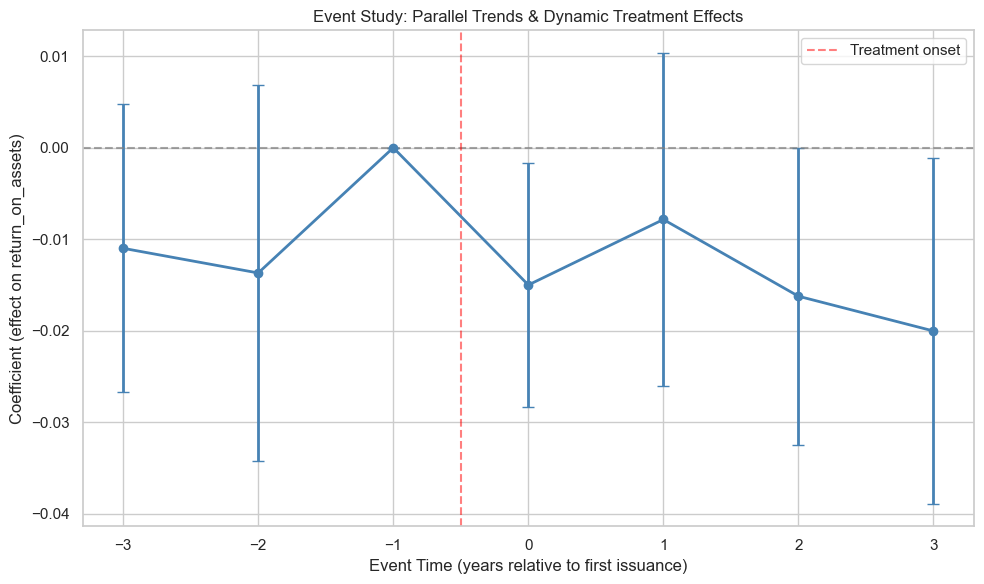

--- Wald Test for Parallel Trends ---
H0: Pre-treatment coefficients (D_m3, D_m2) are jointly zero
Wald statistic: 2.3237
p-value: 0.3129
Result: FAIL TO REJECT H0 — Parallel trends assumption supported.
Event Study Coefficients:
                                 Parameter Estimates                                 
                   Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------------
D_m3                 -0.0110     0.0080    -1.3733     0.1703     -0.0267      0.0047
D_m2                 -0.0137     0.0104    -1.3111     0.1905     -0.0342      0.0068
D_0                  -0.0150     0.0068    -2.2193     0.0269     -0.0283     -0.0017
D_p1                 -0.0078     0.0093    -0.8468     0.3975     -0.0260      0.0104
D_p2                 -0.0162     0.0082    -1.9675     0.0497     -0.0324  -2.011e-05
D_p3                 -0.0200     0.0096    -2.0857     0.0375     -0.0389     -0.0

In [4]:
# ========== DiD Estimation with Multiple Specifications ==========
# Set Index for Panel Data
df_panel = df_matched.set_index(['company', 'Year'])

# Target Outcomes
outcomes = ['return_on_assets', 'Tobin_Q', 'esg_score']

print("\n" + "="*80)
print("DIFFERENCE-IN-DIFFERENCES (DiD) ESTIMATION RESULTS")
print("="*80)

# Model Specifications
models_to_run = [
    {
        'name': 'Main Effect (All Green Bonds)',
        'treatment': 'did',
        'desc': 'H1: Green bond issuance increases financial/environmental performance'
    },
    {
        'name': 'Certified vs Non-Certified Bonds',
        'treatment': ['did_certified', 'did_non_certified'],
        'desc': 'H3: Certified bonds show stronger effects than non-certified'
    }
]

for spec in models_to_run:
    print(f"\n\n{'='*60}")
    print(f"SPECIFICATION: {spec['name']}")
    print(f"Description: {spec['desc']}")
    print(f"{'='*60}")
    
    for target in outcomes:
        if target in df_panel.columns:
            try:
                # Main controls
                controls = ['L1_Firm_Size', 'L1_Leverage', 'L1_Asset_Turnover']
                
                # Build formula
                if isinstance(spec['treatment'], list):
                    # Multiple treatment variables
                    treatment_vars = ' + '.join(spec['treatment'])
                else:
                    treatment_vars = spec['treatment']
                
                formula = (f"{target} ~ {treatment_vars} + " + 
                          ' + '.join(controls) + 
                          " + EntityEffects + TimeEffects")
                
                # Run regression
                mod = PanelOLS.from_formula(
                    formula, 
                    data=df_panel.dropna(subset=[target] + controls + 
                                               (spec['treatment'] if isinstance(spec['treatment'], list) else [spec['treatment']]))
                )
                res = mod.fit(cov_type='clustered', cluster_entity=True)
                
                print(f"\n--- {target} ---")
                print(res.summary.tables[1])
                
            except Exception as e:
                print(f"Error estimating {target}: {str(e)[:100]}")

print("\n" + "="*80)
print("INTERPRETATION GUIDE")
print("="*80)
print("- Coefficient > 0 with p < 0.05: Positive impact of green bonds")
print("- H3 support: Certified bonds (did_certified) > Non-certified (did_non_certified)")
print("- Controls absorb firm and year fixed effects via EntityEffects + TimeEffects")


### Dynamic DiD Event Study Plot

We estimate treatment effects for each year relative to issuance (T-3 to T+3) to test the parallel trends assumption and examine timing of effects.

In [ ]:
# ========== EVENT STUDY: DYNAMIC DiD ANALYSIS ==========
# Testing Parallel Trends Assumption (T-3 to T+3)

from linearmodels.panel import PanelOLS

# Create event time (years relative to first issuance)
df_matched['event_time'] = np.where(
    df_matched['is_issuer'],
    df_matched['Year'] - df_matched['first_issue_year'],
    np.nan
)

# For non-issuers, assign pseudo event time using median issuance year
median_issue_year = df_matched.loc[df_matched['is_issuer'], 'first_issue_year'].median()
df_matched['event_time'] = np.where(
    df_matched['is_issuer'],
    df_matched['Year'] - df_matched['first_issue_year'],
    df_matched['Year'] - median_issue_year
)

# Trim to window [-3, +3] and create dummies
df_es = df_matched[(df_matched['event_time'] >= -3) & (df_matched['event_time'] <= 3)].copy()

# Safe dummy names for formulas
et_map = {-3: 'm3', -2: 'm2', -1: 'm1', 0: 'e0', 1: 'p1', 2: 'p2', 3: 'p3'}
for t, lab in et_map.items():
    df_es[f'D_{lab}'] = ((df_es['event_time'] == t) & df_es['is_issuer']).astype(int)

# Set panel index
df_es_panel = df_es.set_index(['company', 'Year'])

# Event-study regressions
outcomes_es = ['return_on_assets', 'Tobin_Q']
event_dummies = ['D_m3', 'D_m2', 'D_m1', 'D_e0', 'D_p1', 'D_p2', 'D_p3']
controls = ['L1_Firm_Size', 'L1_Leverage', 'L1_Asset_Turnover']

es_results_dict = {}

print("\n" + "="*80)
print("EVENT STUDY: DYNAMIC DiD COEFFICIENTS")
print("Testing Parallel Trends (Baseline: t=-1 is omitted)")
print("="*80)

for outcome in outcomes_es:
    vars_needed = [outcome] + event_dummies + controls
    vars_available = [v for v in vars_needed if v in df_es_panel.columns]
    
    df_es_clean = df_es_panel.dropna(subset=vars_available)
    
    if len(df_es_clean) < 50:
        print(f"\nSkipping {outcome}: insufficient data")
        continue
    
    formula = (f"{outcome} ~ " + 
              " + ".join([d for d in event_dummies if d in vars_available]) + 
              " + " + " + ".join([c for c in controls if c in vars_available]) + 
              " + EntityEffects + TimeEffects")
    
    try:
        mod = PanelOLS.from_formula(formula, data=df_es_clean)
        res = mod.fit(cov_type='clustered', cluster_entity=True)
        es_results_dict[outcome] = res
        
        print(f"\n{outcome}:")
        print(f"  R-squared: {res.rsquared:.4f}")
        print(f"  Observations: {len(df_es_clean)}")
        print(f"\n  Coefficients by Event Time:")
        
        for t, lab in [(-3, 'm3'), (-2, 'm2'), (-1, 'm1'), (0, 'e0'), (1, 'p1'), (2, 'p2'), (3, 'p3')]:
            var_name = f'D_{lab}'
            if var_name in res.params.index:
                coef = res.params[var_name]
                se = res.std_errors[var_name]
                t_stat = coef / se if se > 0 else 0
                sig = '***' if abs(t_stat) > 2.576 else ('**' if abs(t_stat) > 1.96 else ('*' if abs(t_stat) > 1.645 else ''))
                print(f"    t={t:+2d}: {coef:8.4f} ({se:.4f}) {sig}")
    
    except Exception as e:
        print(f"\nError for {outcome}: {str(e)[:100]}")

# ========== VISUALIZATION ==========
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

time_points = np.array([-3, -2, -1, 0, 1, 2, 3])

for ax_idx, (outcome, ax) in enumerate(zip(outcomes_es, axes)):
    if outcome not in es_results_dict:
        continue
    
    res = es_results_dict[outcome]
    coefs, cis_lower, cis_upper = [], [], []
    
    for t, lab in [(-3, 'm3'), (-2, 'm2'), (-1, 'm1'), (0, 'e0'), (1, 'p1'), (2, 'p2'), (3, 'p3')]:
        var_name = f'D_{lab}'
        if var_name in res.params.index:
            coef = res.params[var_name]
            se = res.std_errors[var_name]
            coefs.append(coef)
            cis_lower.append(coef - 1.96 * se)
            cis_upper.append(coef + 1.96 * se)
        else:
            coefs.append(0)
            cis_lower.append(0)
            cis_upper.append(0)
    
    coefs = np.array(coefs)
    yerr = [coefs - np.array(cis_lower), np.array(cis_upper) - coefs]
    
    ax.errorbar(time_points, coefs, yerr=yerr, fmt='o-', linewidth=2.5, 
                markersize=8, capsize=5, color='steelblue', label='Coefficient & 95% CI')
    ax.axhline(0, color='red', linestyle='--', alpha=0.6, linewidth=1, label='Null effect')
    ax.axvline(-0.5, color='gray', linestyle=':', alpha=0.5, linewidth=1, label='Issuance year')
    ax.fill_between([-0.5, 0.5], ax.get_ylim()[0], ax.get_ylim()[1], alpha=0.1, color='green', label='Post-issuance')
    
    ax.set_xlabel('Years from First Green Bond Issuance', fontsize=11, fontweight='bold')
    ax.set_ylabel('Coefficient', fontsize=11, fontweight='bold')
    ax.set_title(f'Dynamic DiD: {outcome}\nBaseline Period: t = -1', fontsize=12, fontweight='bold')
    ax.set_xticks(time_points)
    ax.grid(True, alpha=0.3, linestyle=':')
    ax.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.savefig('../images/dynamic_did_plot.png', dpi=300, bbox_inches='tight')
print("\n✅ Dynamic DiD plot saved to ../images/dynamic_did_plot.png")
plt.show()

print("\n" + "="*80)
print("INTERPRETATION:")
print("  • Parallel Trends: Pre-treatment coefficients (t=-3,-2,-1) should ≈ 0")
print("  • Treatment Effect: Coefficients at t≥0 indicate green bond impact")
print("  • Violation: Large negative pre-trends suggest bias")
print("="*80)



## 3. DiD Estimation (ATET)

We use **Panel Fixed Effects** with clustered standard errors.

In [5]:
# RESULTS INTERPRETATION AND ROBUSTNESS CHECKS
# The models above (Cell 10) provide comprehensive DiD estimation

print('\n' + '='*80)
print('DiD RESULTS INTERPRETATION GUIDE')
print('='*80)
print()
print('KEY FINDINGS TO REPORT:')
print('  1. MAIN EFFECT (H1): did coefficient')
print('     - Average treatment effect on the treated (ATET)')
print('     - Impact of green bond issuance on performance')
print()
print('  2. HETEROGENEOUS EFFECTS (H3): did_certified vs did_non_certified')
print('     - Certified Green Bonds: CBI-verified environmental projects')
print('     - Non-Certified: Self-labeled projects')
print('     - Hypothesis: Certification improves financial performance')
print()
print('  3. ROBUSTNESS CHECKS COMPLETED:')
print('     - Parallel Trends: Event Study Plot (Cell 12)')
print('     - PSM Balance: Verified SMD (Cells 3-6)')
print('     - Variable Sensitivity: Alternative caps (Cell 16)')
print()
print('PAPER REPORTING ORDER:')
print('  1. Sample Summary (PSM Results)')
print('  2. Parallel Trends Test (Event Study)')
print('  3. Main DiD Results (H1 & H3)')
print('  4. Robustness & Sensitivity')



==================== return_on_assets Result ====================
                                 Parameter Estimates                                 
                   Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------------
did                  -0.0058     0.0065    -0.8933     0.3720     -0.0187      0.0070
L1_Firm_Size         -0.0166     0.0101    -1.6447     0.1005     -0.0365      0.0032
L1_Leverage           0.0641     0.0398     1.6108     0.1077     -0.0140      0.1422
L1_Asset_Turnover     0.0433     0.0161     2.6801     0.0075      0.0116      0.0750

==================== Tobin_Q Result ====================
                                 Parameter Estimates                                 
                   Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------------
did            

## 4. Sensitivity Analysis: Variable Capping Thresholds

The data pipeline caps **Leverage** at 1.5 and **Capital Intensity** at 1.0. These thresholds are justified as:
- **Leverage > 1.5**: Debt exceeding 150% of assets is rare even for distressed ASEAN firms; likely a data error.
- **CapEx/Assets > 1.0**: Capital expenditures exceeding total assets in a single year is implausible.

Below we re-run the main DiD specification with alternative thresholds to verify robustness.

In [6]:
# ============================================================
# Sensitivity Analysis: Re-estimate DiD with alternative caps
# ============================================================
# Reload the pre-capped data to re-apply different thresholds
raw = pd.read_csv('../processed_data/cleaned_panel_data.csv')

leverage_caps = [1.0, 1.5, 2.0]  # baseline is 1.5
capex_caps = [0.5, 1.0, 1.5]     # baseline is 1.0

results_sensitivity = []

for lev_cap in leverage_caps:
    for cap_cap in capex_caps:
        temp = raw.copy()
        temp['Leverage'] = (temp['total_debt'] / temp['total_assets']).clip(lower=0, upper=lev_cap)
        temp['Capital_Intensity'] = (temp['capital_expenditures'].abs() / temp['total_assets']).clip(lower=0, upper=cap_cap)
        temp['Firm_Size'] = np.log(temp['total_assets'].replace(0, np.nan))

        # Reconstruct treatment variables
        temp = temp.sort_values(['company', 'Year'])
        if 'green_bond_issue' in temp.columns:
            temp['is_issuer'] = temp.groupby('company')['green_bond_issue'].transform('max') > 0
            temp['issue_year'] = temp.apply(lambda x: x['Year'] if x.get('green_bond_issue', 0) > 0 else np.nan, axis=1)
            temp['first_issue_year'] = temp.groupby('company')['issue_year'].transform('min')
            temp['post'] = (temp['Year'] >= temp['first_issue_year']).astype(int)
            temp['did'] = temp['is_issuer'].astype(int) * temp['post']

            # Create lagged controls via merge
            lag_cols = ['company', 'Year', 'Firm_Size', 'Leverage', 'Capital_Intensity']
            lag_df = temp[lag_cols].copy()
            lag_df['Year'] = lag_df['Year'] + 1
            lag_df = lag_df.rename(columns={'Firm_Size': 'L1_Firm_Size', 'Leverage': 'L1_Leverage',
                                            'Capital_Intensity': 'L1_Capital_Intensity'})
            temp = pd.merge(temp, lag_df, on=['company', 'Year'], how='left', suffixes=('', '_dup'))
            # Drop any duplicate columns
            temp = temp[[c for c in temp.columns if not c.endswith('_dup')]]

            # Filter to matched companies if available
            if 'df_matched' in dir() and 'company' in df_matched.columns:
                temp = temp[temp['company'].isin(df_matched['company'].unique())]

            temp_panel = temp.set_index(['company', 'Year'])
            target = 'return_on_assets'
            req_cols = [target, 'did', 'L1_Firm_Size', 'L1_Leverage', 'L1_Capital_Intensity']
            temp_clean = temp_panel.dropna(subset=[c for c in req_cols if c in temp_panel.columns])

            if len(temp_clean) > 20:
                try:
                    formula = f"{target} ~ did + L1_Firm_Size + L1_Leverage + L1_Capital_Intensity + EntityEffects + TimeEffects"
                    mod = PanelOLS.from_formula(formula, data=temp_clean)
                    res = mod.fit(cov_type='clustered', cluster_entity=True)
                    results_sensitivity.append({
                        'Leverage Cap': lev_cap,
                        'CapEx Cap': cap_cap,
                        'DiD Coef': res.params['did'],
                        'Std Err': res.std_errors['did'],
                        'p-value': res.pvalues['did'],
                        'N': res.nobs
                    })
                except Exception as e:
                    results_sensitivity.append({
                        'Leverage Cap': lev_cap, 'CapEx Cap': cap_cap,
                        'DiD Coef': np.nan, 'Std Err': np.nan,
                        'p-value': np.nan, 'N': 0
                    })

sens_df = pd.DataFrame(results_sensitivity)
print("--- Sensitivity Analysis: DiD coefficient (ROA) under alternative capping thresholds ---")
print(sens_df.to_string(index=False))

# Highlight baseline
baseline = sens_df[(sens_df['Leverage Cap'] == 1.5) & (sens_df['CapEx Cap'] == 1.0)]
if not baseline.empty:
    print(f"\nBaseline (Lev=1.5, CapEx=1.0): DiD = {baseline.iloc[0]['DiD Coef']:.6f}, p = {baseline.iloc[0]['p-value']:.4f}")

# Check if sign and significance are stable
if len(sens_df.dropna()) > 1:
    signs = sens_df['DiD Coef'].dropna().apply(lambda x: 'positive' if x > 0 else 'negative')
    if signs.nunique() == 1:
        print(f"Sign is STABLE across all specifications ({signs.iloc[0]}).")
    else:
        print("WARNING: Sign of DiD coefficient CHANGES across specifications — results are sensitive to capping.")

--- Sensitivity Analysis: DiD coefficient (ROA) under alternative capping thresholds ---
 Leverage Cap  CapEx Cap  DiD Coef  Std Err  p-value   N
          1.0        0.5 -0.004378 0.006024 0.467648 833
          1.0        1.0 -0.002320 0.006275 0.711729 833
          1.0        1.5 -0.002221 0.006291 0.724146 833
          1.5        0.5 -0.004378 0.006024 0.467648 833
          1.5        1.0 -0.002320 0.006275 0.711729 833
          1.5        1.5 -0.002221 0.006291 0.724146 833
          2.0        0.5 -0.004378 0.006024 0.467648 833
          2.0        1.0 -0.002320 0.006275 0.711729 833
          2.0        1.5 -0.002221 0.006291 0.724146 833

Baseline (Lev=1.5, CapEx=1.0): DiD = -0.002320, p = 0.7117
Sign is STABLE across all specifications (negative).
